# Lab 5: Semi-gradient SARSA with tile coding on MountainCar-v0

In [11]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

LOW = np.array([-1.2, -0.07])
HIGH = np.array([0.6, 0.07])
N_ACTIONS = 3

## 1. Tile coding feature constructor

In [12]:
class TileCoder:
    def __init__(self, n_tilings=8, n_tiles=8, low=LOW, high=HIGH):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.low = low
        self.tile_width = (high - low) / n_tiles
        offsets = np.arange(n_tilings)[:, None] * np.array([1, 3]) / n_tilings
        self.offsets = offsets * self.tile_width
        self.tiles_per_tiling = (n_tiles + 1) ** 2
        self.n_features = n_tilings * self.tiles_per_tiling

    def active_indices(self, s):
        shifted = (s + self.offsets - self.low) / self.tile_width
        ij = np.clip(np.floor(shifted).astype(int), 0, self.n_tiles)
        flat = ij[:, 0] * (self.n_tiles + 1) + ij[:, 1]
        return flat + np.arange(self.n_tilings) * self.tiles_per_tiling

## 2. Semi-gradient SARSA

In [13]:
def q_values(w, idx):
    return w[:, idx].sum(axis=1)

def eps_greedy(w, idx, eps, rng):
    if rng.random() < eps:
        return int(rng.integers(N_ACTIONS))
    return int(np.argmax(q_values(w, idx)))

def sarsa(env, tc, n_episodes, alpha, eps, gamma, seed, max_steps=1000):
    rng = np.random.default_rng(seed)
    w = np.zeros((N_ACTIONS, tc.n_features))
    alpha_eff = alpha / tc.n_tilings
    steps_per_ep = np.zeros(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset(seed=int(seed * 10007 + ep))
        idx = tc.active_indices(s)
        a = eps_greedy(w, idx, eps, rng)
        for t in range(max_steps):
            s2, r, terminated, truncated, _ = env.step(a)
            idx2 = tc.active_indices(s2)
            q_sa = w[a, idx].sum()
            if terminated:
                w[a, idx] += alpha_eff * (r - q_sa)
                break
            a2 = eps_greedy(w, idx2, eps, rng)
            target = r + gamma * w[a2, idx2].sum()
            w[a, idx] += alpha_eff * (target - q_sa)
            s, idx, a = s2, idx2, a2
            if truncated:
                break
        steps_per_ep[ep] = t + 1
    return w, steps_per_ep

## 3. Train (8 tilings × 8×8, 10 seeds, 500 episodes)

In [14]:
env = gym.make("MountainCar-v0")
tc = TileCoder(8, 8)
N_EP, ALPHA, EPS, GAMMA, N_SEEDS = 500, 0.5, 0.0, 1.0, 10

all_steps = np.zeros((N_SEEDS, N_EP))
for s in range(N_SEEDS):
    _, all_steps[s] = sarsa(env, tc, N_EP, ALPHA, EPS, GAMMA, seed=s)
w_main, _ = sarsa(env, tc, N_EP, ALPHA, EPS, GAMMA, seed=0)
print(f"features={tc.n_features}, last-50 mean steps = {all_steps[:, -50:].mean():.1f}")

features=648, last-50 mean steps = 118.2


## 4. Feature-configuration sweep

In [15]:
configs = [(4, 8), (8, 8), (16, 8), (8, 4)]
conv = {}
for nT, nt in configs:
    tc_v = TileCoder(nT, nt)
    runs = np.array([sarsa(env, tc_v, N_EP, ALPHA, EPS, GAMMA, seed=s)[1] for s in range(5)])
    conv[(nT, nt)] = runs
    print(f"{nT} tilings x {nt}x{nt}: features={tc_v.n_features}, last-50={runs[:, -50:].mean():.1f}")

4 tilings x 8x8: features=324, last-50=137.3
8 tilings x 8x8: features=648, last-50=117.2
16 tilings x 8x8: features=1296, last-50=110.7
8 tilings x 4x4: features=200, last-50=151.2


## 5. Visualizations

In [16]:
def grid_q(w, tc, n=60):
    pos = np.linspace(LOW[0], HIGH[0], n)
    vel = np.linspace(LOW[1], HIGH[1], n)
    P, V = np.meshgrid(pos, vel)
    Qmax = np.zeros_like(P); Pol = np.zeros_like(P, dtype=int)
    for i in range(n):
        for j in range(n):
            qs = q_values(w, tc.active_indices(np.array([P[i, j], V[i, j]])))
            Qmax[i, j] = qs.max(); Pol[i, j] = qs.argmax()
    return pos, vel, Qmax, Pol

pos, vel, Qmax, Pol = grid_q(w_main, tc)

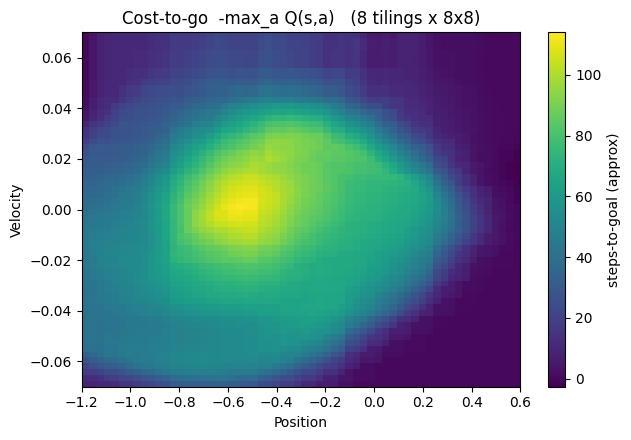

In [17]:
# Fig 1: cost-to-go heatmap
fig, ax = plt.subplots(figsize=(6.5, 4.5))
im = ax.imshow(-Qmax, origin="lower", aspect="auto",
               extent=[LOW[0], HIGH[0], LOW[1], HIGH[1]], cmap="viridis")
ax.set_xlabel("Position"); ax.set_ylabel("Velocity")
ax.set_title("Cost-to-go  -max_a Q(s,a)   (8 tilings x 8x8)")
plt.colorbar(im, ax=ax, label="steps-to-goal (approx)")
fig.tight_layout(); plt.show()

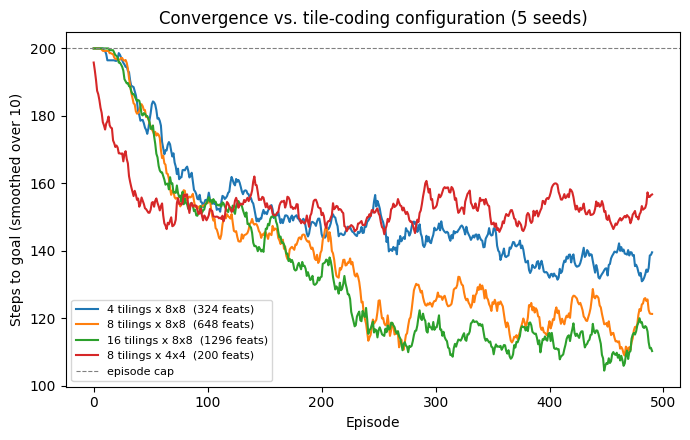

In [18]:
# Fig 2: convergence for different configs
fig, ax = plt.subplots(figsize=(7, 4.5))
for (nT, nt), runs in conv.items():
    m = runs.mean(axis=0)
    smoothed = np.convolve(m, np.ones(10)/10, mode="valid")
    ax.plot(smoothed, label=f"{nT} tilings x {nt}x{nt}  ({TileCoder(nT, nt).n_features} feats)")
ax.axhline(200, color="grey", ls="--", lw=0.8, label="episode cap")
ax.set_xlabel("Episode"); ax.set_ylabel("Steps to goal (smoothed over 10)")
ax.set_title("Convergence vs. tile-coding configuration (5 seeds)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

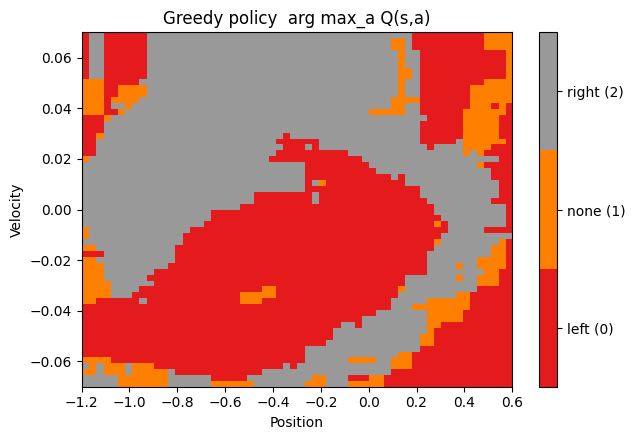

In [19]:
# Fig 3: learned policy
fig, ax = plt.subplots(figsize=(6.5, 4.5))
cmap = plt.get_cmap("Set1", 3)
im = ax.imshow(Pol, origin="lower", aspect="auto",
               extent=[LOW[0], HIGH[0], LOW[1], HIGH[1]], cmap=cmap, vmin=-0.5, vmax=2.5)
ax.set_xlabel("Position"); ax.set_ylabel("Velocity")
ax.set_title("Greedy policy  arg max_a Q(s,a)")
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["left (0)", "none (1)", "right (2)"])
fig.tight_layout(); plt.show()

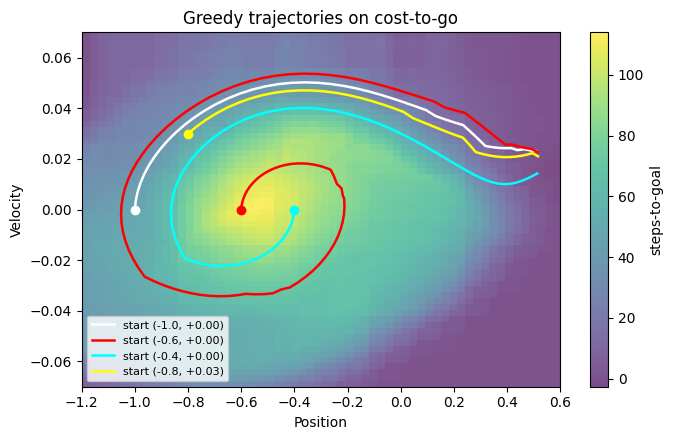

In [20]:
# Fig 4: sample trajectories on the value function
def rollout(w, tc, p0, v0=0.0, max_steps=200):
    env_r = gym.make("MountainCar-v0"); env_r.reset(seed=0)
    env_r.unwrapped.state = np.array([p0, v0])
    traj = [env_r.unwrapped.state.copy()]
    for _ in range(max_steps):
        a = int(np.argmax(q_values(w, tc.active_indices(env_r.unwrapped.state))))
        s2, _, terminated, truncated, _ = env_r.step(a)
        traj.append(s2.copy())
        if terminated or truncated: break
    return np.array(traj)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(-Qmax, origin="lower", aspect="auto",
               extent=[LOW[0], HIGH[0], LOW[1], HIGH[1]], cmap="viridis", alpha=0.7)
for (p0, v0), c_ in zip([(-1.0, 0.0), (-0.6, 0.0), (-0.4, 0.0), (-0.8, 0.03)],
                         ["white", "red", "cyan", "yellow"]):
    traj = rollout(w_main, tc, p0, v0)
    ax.plot(traj[:, 0], traj[:, 1], color=c_, lw=1.8, label=f"start ({p0:+.1f}, {v0:+.2f})")
    ax.plot(traj[0, 0], traj[0, 1], "o", color=c_, markersize=6)
ax.set_xlabel("Position"); ax.set_ylabel("Velocity")
ax.set_title("Greedy trajectories on cost-to-go")
ax.legend(fontsize=8, loc="lower left")
plt.colorbar(im, ax=ax, label="steps-to-goal")
fig.tight_layout(); plt.show()